# Modelado Avanzado y Stacking

En este notebook llevaremos el análisis al siguiente nivel:
1. **Generación de Targets**: Usaremos Clustering para definir perfiles (target).
2. **PCA**: Reducción de dimensionalidad para visualizar la separabilidad.
3. **Stacking Classifier**: Entrenaremos un ensamble de modelos (RF, XGB, SVM) para clasificar estos perfiles con máxima precisión.
4. **Explicabilidad (SHAP)**: Entenderemos qué variables definen cada perfil.

In [1]:
%pip install numpy==2.3.0

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Add src to path
sys.path.append(os.path.abspath(os.path.join('..', 'src')))

from models.train_model import train_stacking_ensemble, evaluate_models_cv
from visualization.visualize import plot_confusion_matrix, plot_shap_summary, plot_pca_2d

%matplotlib inline

## 1. Preparación de Datos y Variable Objetivo

In [3]:
data_path = '../data/processed/final_dataset_with_features.csv'
df = pd.read_csv(data_path, index_col=0)
print(f"N total: {len(df)}")

# Limpieza de nulos
df_clean = df.dropna()
print(f"N despues de dropna: {len(df_clean)}")

# Seleccionamos features numéricas relevantes para el perfilado
features_cols = [
    'stroop_interference', 'flanker_interference', 
    'stroop_rt_mean_recalc', 'flanker_rt_mean_recalc',
    'stroop_rt_std', 'flanker_rt_std',
    'sart_error_rate', 'stroop_error_rate'
]
features_cols = [c for c in features_cols if c in df_clean.columns]
X = df_clean[features_cols]

# Estandarizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_sin_scaled = X

N total: 466
N despues de dropna: 466


In [4]:
X_scaled
#X_sin_scaled

array([[ 0.56143819, -0.80314678, -0.3351432 , ..., -0.61971801,
        -1.74586805,  0.15167768],
       [ 0.51527895, -0.2983507 ,  1.59063412, ...,  3.20180864,
         1.56645876, -0.34660568],
       [-0.24991253, -1.01185326, -0.34929077, ...,  0.07808234,
         0.58669611, -0.70251618],
       ...,
       [-0.1364027 , -1.45709851, -1.28289199, ..., -1.26576486,
        -0.99250767, -0.04414209],
       [ 0.70717201,  1.0826071 ,  0.50361163, ...,  0.71614884,
         0.24063621,  0.76828561],
       [ 0.65676655,  0.13227308, -0.59229274, ...,  0.01240924,
         0.16698865, -0.08037659]], shape=(466, 8))

## 2. Generación de Target (Clustering)
Creamos 3 perfiles teóricos (ej. Alto Rendimiento, Impulsivo, Lento).
Esto se convierte en nuestra **y** (variable a predecir).

In [5]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)
df_clean['Profile_Cluster'] = labels

# Visualizar tamaños
print(df_clean['Profile_Cluster'].value_counts())

Profile_Cluster
2    228
1    151
0     87
Name: count, dtype: int64


/Users/isabelsalinas/Documents/Documentos TFG/TFG-Control_inhibitorio_atencion/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/isabelsalinas/Documents/Documentos TFG/TFG-Control_inhibitorio_atencion/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/isabelsalinas/Documents/Documentos TFG/TFG-Control_inhibitorio_atencion/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


## 3. Análisis de Componentes Principales (PCA)
Utilizamos PCA para reducir la dimensionalidad y visualizar la separabilidad de los clusters.

/Users/isabelsalinas/Documents/Documentos TFG/TFG-Control_inhibitorio_atencion/.venv/lib/python3.12/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/isabelsalinas/Documents/Documentos TFG/TFG-Control_inhibitorio_atencion/.venv/lib/python3.12/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/isabelsalinas/Documents/Documentos TFG/TFG-Control_inhibitorio_atencion/.venv/lib/python3.12/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


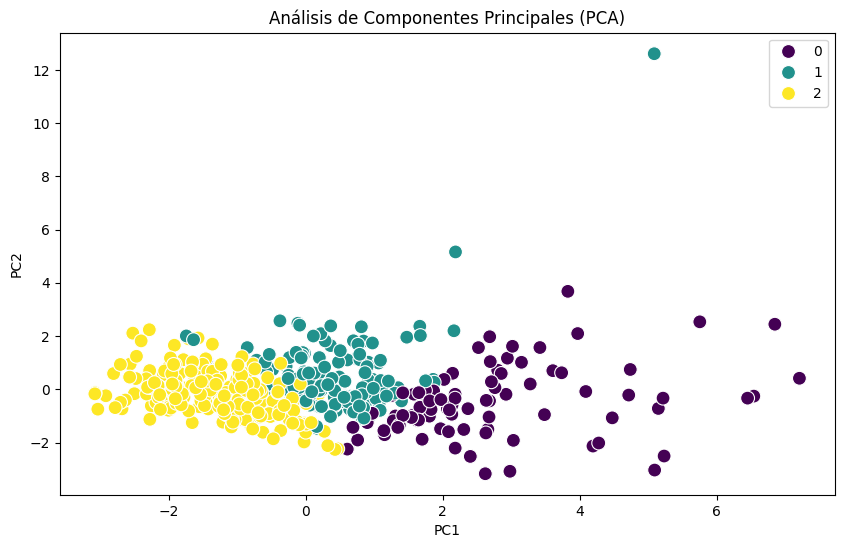

Varianza explicada por PC1 y PC2: 56.06%


In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plot_pca_2d(X_pca, labels)

# Varianza explicada
print(f"Varianza explicada por PC1 y PC2: {pca.explained_variance_ratio_.sum():.2%}")

## 4. Entrenamiento y Stacking Classifier
Ahora tratamos de predecir este perfil usando técnicas supervisadas. 
¿Podemos predecir el perfil con alta precisión en datos nuevos?
Usaremos:
- RandomForest
- SVM
- XGBoost
- **Stacking (Combinación de todos)**

--- Validación Cruzada (cv=5) ---
RandomForest: 0.9162 (+/- 0.0316)


/Users/isabelsalinas/Documents/Documentos TFG/TFG-Control_inhibitorio_atencion/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [19:00:32] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/isabelsalinas/Documents/Documentos TFG/TFG-Control_inhibitorio_atencion/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [19:00:33] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/isabelsalinas/Documents/Documentos TFG/TFG-Control_inhibitorio_atencion/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [19:00:33] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/isabelsalinas/Documents/

XGBoost: 0.9034 (+/- 0.0139)
SVM: 0.9485 (+/- 0.0159)
Entrenando Stacking Ensemble...


/Users/isabelsalinas/Documents/Documentos TFG/TFG-Control_inhibitorio_atencion/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [19:00:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/isabelsalinas/Documents/Documentos TFG/TFG-Control_inhibitorio_atencion/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [19:00:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/isabelsalinas/Documents/Documentos TFG/TFG-Control_inhibitorio_atencion/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [19:00:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/isabelsalinas/Documents/


--- Resultados del Stacking Classifier ---

              precision    recall  f1-score   support

           0       1.00      0.81      0.89        26
           1       0.91      0.93      0.92        45
           2       0.95      1.00      0.97        69

    accuracy                           0.94       140
   macro avg       0.95      0.91      0.93       140
weighted avg       0.95      0.94      0.94       140



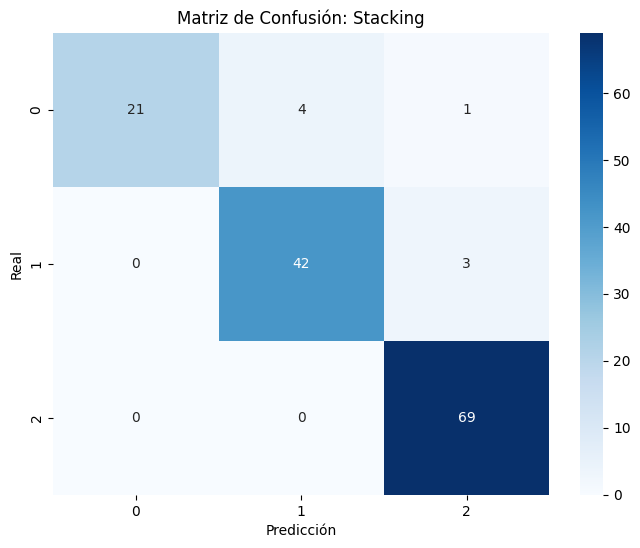

In [7]:
y = df_clean['Profile_Cluster']

# 1. Evaluar modelos individuales con Cross-Validation
results = evaluate_models_cv(X_scaled, y)

# 2. Entrenar Stacking Final
stacking_model, X_test, y_test, y_pred = train_stacking_ensemble(X_scaled, y)

# 3. Matriz de Confusión
plot_confusion_matrix(y_test, y_pred, title="Matriz de Confusión: Stacking")

## 5. Explicabilidad con SHAP
Analizamos qué características son las más decisivas para que el modelo asigne un perfil.
Utilizamos el Random Forest base del Stacking para la interpretación (TreeExplainer).

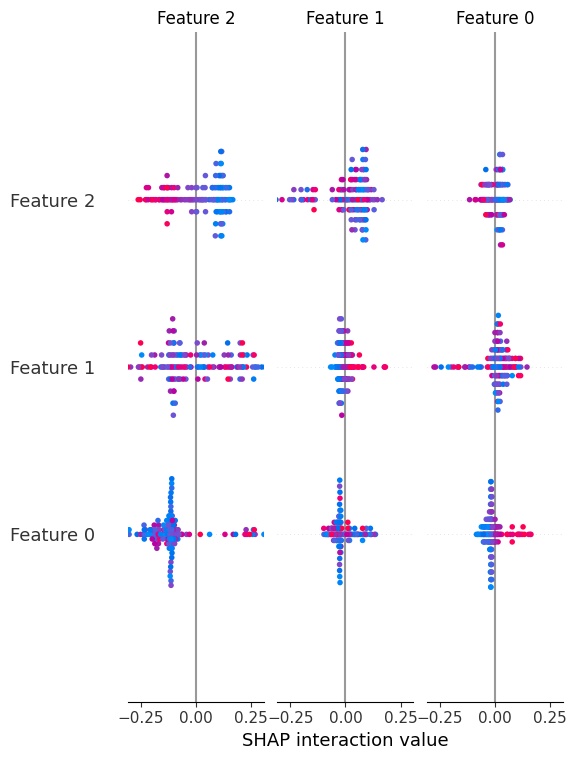

In [8]:
# Extraemos el RandomForest del Stacking
rf_model = stacking_model.named_estimators_['rf']

# Generar SHAP Plot
plot_shap_summary(rf_model, X_test, model_type='tree')